In [4]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pyogrio


from pyogrio import list_layers







# Figure 2.1: Data for the regional dispersion of housing prices
I first construct the left panel, where the data comes from OECD's public database, and can be found in Figur 2.1 (right).xlsx


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'Figur 2.1 (right).xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Master', header=None)


def is_country_label(value):
    if not isinstance(value, str):
        return False
    value = value.strip()
    return (value != '') and ('-Q' not in value)


country_rows = [(i, df_raw.iat[i, 0].strip()) for i in range(len(df_raw)) if is_country_label(df_raw.iat[i, 0])]

base_label = '2009-Q2'
results_index_sd = {}

for block_i, (start_row, country) in enumerate(country_rows):
    end_row = country_rows[block_i + 1][0] if block_i + 1 < len(country_rows) else len(df_raw)

    period_labels = df_raw.iloc[start_row + 1, 1:].dropna().astype(str).to_numpy()
    n_periods = len(period_labels)

    if base_label not in period_labels:
        continue

    base_idx = int(np.where(period_labels == base_label)[0][0])

    data_block = df_raw.iloc[start_row + 2:end_row, 1:1 + n_periods].apply(pd.to_numeric, errors='coerce')

    # Reconstruct only the same quarter-of-year chain as the base (Q2)
    regional_q2_indices = []
    for _, row in data_block.iterrows():
        g = row.to_numpy(dtype=float)  # y-o-y growth in percent

        idx = np.full(n_periods, np.nan)
        idx[base_idx] = 100.0

        for t in range(base_idx + 4, n_periods, 4):
            prev_t = t - 4
            if np.isfinite(idx[prev_t]) and np.isfinite(g[t]):
                idx[t] = idx[prev_t] * (1.0 + g[t] / 100.0)

        q2_path = idx[base_idx::4]

        # Keep region only if enough annual points in reconstructed chain
        if np.sum(np.isfinite(q2_path)) >= 4:
            regional_q2_indices.append(q2_path)

    if len(regional_q2_indices) == 0:
        continue

    regional_q2_indices = np.vstack(regional_q2_indices)
    q2_labels = period_labels[base_idx::4]
    years = np.array([int(label.split('-')[0]) for label in q2_labels], dtype=int)

    valid_counts = np.sum(np.isfinite(regional_q2_indices), axis=0)
    with np.errstate(invalid='ignore', divide='ignore'):
        sd_year = np.nanstd(regional_q2_indices, axis=0, ddof=1)
    sd_year[valid_counts < 2] = np.nan

    results_index_sd[country] = (years, sd_year)

Then getting the data for the left panel of figure 2.1:

In [6]:
import numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import openpyxl

# ── Pretty style (mirrors set_plot_style / plot_makro_lifecycle_profiles) ──
mpl.rcParams.update({
    'font.family': 'Patalino',
    'mathtext.fontset': 'stix', 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'figure.titlesize': 14, 'font.size': 11,
})

# region rows are in the same order in all three blocks (weights 2-6, SFH 9-13, apt 14-18)
REGIONS = [   # (xlsx label, display name, colour, linestyle)
    ('Capital Region',    'Capital Region',   'black',   '-'),
    ('Zealand Region',    'Zealand Region',   '#003C8F', '-'),
    ('Central Denmark',   'Central Denmark',  '#C92828', '-'),
    ('Sourthern Denmark', 'Southern Denmark', '#1F7A1F', '-'),
    ('North Denmark',     'North Denmark',    '#E08214', '-'),
]

def load_regional_prices(path='Figure 2.1 (left).xlsx', annual=True):
    """Composite DKK/m² = w·P_singlefamily + (1−w)·P_apartment, per region.

    Annual SFH weights (rows 2-6) apply to all four quarters of their year;
    quarterly prices are SFH (rows 9-13) and apartments (rows 14-18).
    annual=True averages the four quarters of each year into one value
    (partial final years average whatever quarters are present)."""
    ws = openpyxl.load_workbook(path, data_only=True).active
    n = ws.max_column
    wyears   = [ws.cell(1, c).value for c in range(2, n + 1)]   # annual headers
    quarters = [ws.cell(8, c).value for c in range(2, n + 1)]   # 'YYYYKk' headers
    row = lambda r: [ws.cell(r, c).value for c in range(2, n + 1)]
    out = {}
    for i, (_, disp, _, _) in enumerate(REGIONS):
        wmap = {int(y): float(v) for y, v in zip(wyears, row(2 + i))
                if y is not None and v is not None}
        last_w = wmap[max(wmap)]                                # forward-fill tail years
        sfh, apt = row(9 + i), row(14 + i)
        x_dec, yr_arr, comp = [], [], []
        for q, ps, pa in zip(quarters, sfh, apt):
            if not q or ps is None or pa is None:
                continue
            yr, k = int(str(q)[:4]), int(str(q)[-1])
            w = wmap.get(yr, last_w)
            x_dec.append(yr + (k - 1) / 4.0)                    # quarter → decimal year
            yr_arr.append(yr)
            comp.append(w * float(ps) + (1.0 - w) * float(pa))
        x_dec, yr_arr, comp = map(np.asarray, (x_dec, yr_arr, comp))
        if annual:
            yrs = np.unique(yr_arr)
            x = yrs.astype(float)
            y = np.array([comp[yr_arr == u].mean() for u in yrs])   # mean of the year's quarters
        else:
            x, y = x_dec, comp
        out[disp] = (x, y)
    return out


def plot_regional_prices(ax):
    data = load_regional_prices()
    for _, disp, colour, ls in REGIONS:
        x, y = data[disp]
        ax.plot(x, y, color=colour, ls=ls, lw=2, label=disp)
    ax.set_ylabel('DKK / m$^2$'); ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.set_xlim(1992, 2025)
    ax.legend(frameon=False); ax.grid(False); ax.set_box_aspect(1.0)





<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_39216/2682005515.py:48: SyntaxWarning: invalid escape sequence '\D'
  axR.set_ylabel('$\Delta$HPI std. dev. across regions (2009=100)')


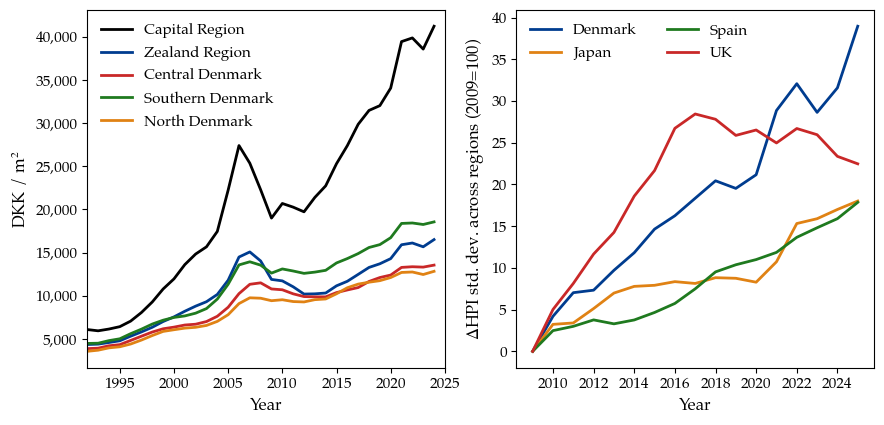

In [7]:

import matplotlib as mpl
from matplotlib.ticker import MaxNLocator


# for pretty graphics
def set_plot_style(font='Times New Roman', math_fontset='stix', base_fontsize=11):
    touched = {
        'font.family':      font,
        'font.serif':       [font, 'DejaVu Serif'],
        'mathtext.fontset': math_fontset,
        'mathtext.rm':      font,
        'mathtext.it':      f'{font}:italic',
        'mathtext.bf':      f'{font}:bold',
        'axes.titlesize':   base_fontsize + 2,
        'axes.labelsize':   base_fontsize,
        'xtick.labelsize':  base_fontsize - 1,
        'ytick.labelsize':  base_fontsize - 1,
        'legend.fontsize':  base_fontsize - 1,
        'figure.titlesize': base_fontsize + 3,
        'font.size':        base_fontsize,
    }
    mpl.rcParams.update(touched)
    return touched

set_plot_style(font='Palatino', base_fontsize=12)

# Overlay in one figure: reconstructed-index annual dispersion
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 6))

# ── Left: regional DKK/m² (reconstructed) ──
plot_regional_prices(axL)

# ── Right: reconstructed regional HPI dispersion (base 2009-Q2 = 100) ──
# matching right-panel colours to the left-panel regional palette
region_colors = {disp: color for _, disp, color, _ in REGIONS}
country_color = {
    'Denmark': region_colors['Zealand Region'],    # blue
    'UK':      region_colors['Central Denmark'],    # red
    'Spain':   region_colors['Southern Denmark'],   # green
    'Japan':   region_colors['North Denmark'],      # orange
}

if 'results_index_sd' not in globals() or len(results_index_sd) == 0:
    raise ValueError("Run the cell that builds 'results_index_sd' first.")
for country, (years, sd_year) in results_index_sd.items():
    axR.plot(years, sd_year, lw=2, color=country_color.get(country), label=country)
axR.set_xlabel('Year')
axR.set_ylabel('$\Delta$HPI std. dev. across regions (2009=100)')
axR.xaxis.set_major_locator(MaxNLocator(integer=True))   # integer year ticks, no decimals
axR.legend(frameon=False, ncol=2)
axR.grid(False)
axR.set_box_aspect(1.0)

fig.tight_layout()
plt.show()






# Figure 2.2: Maps for stylized facts about the Danish housing market
This notebook compiles maps of house prices and urabn densities across Danish postal codes from 1992 to 2024. The data is from the Central Register of Buildings and Dwellings of Denmark (BBR) and the Finance Denmark BM011 database.



### BBR data
First, the BBR-data is inspected:

In [8]:
import pyogrio


#see column names
pyogrio.read_info("DK_INSPIRE_BBR.gpkg")

/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_39216/3632772507.py:5: UserWarning: More than one layer found in 'DK_INSPIRE_BBR.gpkg': 'building' (default), 'otherConstruction'. Specify layer parameter to avoid this warning.
  pyogrio.read_info("DK_INSPIRE_BBR.gpkg")


{'layer_name': 'building',
 'crs': 'EPSG:25832',
 'encoding': 'UTF-8',
 'fields': array(['addressRepresentation', 'beginLifeSpanVersion', 'buildingNature',
        'conditionOfConstruction', 'connectionToElectricity',
        'connectionToGas', 'connectionToSewage', 'connectionToWater',
        'currentUse', 'dateOfConstruction_dateOfEvent_anyPoint',
        'dateOfConstruction_dateOfEvent_begin',
        'dateOfConstruction_dateOfEvent_end', 'dateOfDemolition',
        'dateOfRenovation_dateOfEvent_anyPoint',
        'dateOfRenovation_dateOfEvent_begin',
        'dateOfRenovation_dateOfEvent_end', 'document', 'elevation',
        'endLifeSpanVersion', 'energyPerformance',
        'externalReference_reference1', 'externalReference_reference2',
        'externalReference_system1', 'externalReference_system2',
        'externalReference_systemName1', 'externalReference_systemName2',
        'floorDescription_floorRange', 'floorDescription',
        'geometry_horizontalAccuracy', 'geometr

The necessary observations of the BBR register are loaded (takes around 10 minutes to finish):

In [9]:

_file = "DK_INSPIRE_BBR.gpkg"
_layer = list_layers(_file)[0][0]
bbr = gpd.read_file(
    _file, layer=_layer, engine="pyogrio",
    columns=['officialArea', 'addressRepresentation', 'dateOfConstruction_dateOfEvent_anyPoint', 'dateOfDemolition', 'currentUse', 'endLifeSpanVersion'],
)
#bbr = bbr_full.sample(n=10_000, random_state=42)

print(bbr.info())

# officialArea can arrive as strings — coerce to numeric
bbr['officialArea'] = pd.to_numeric(bbr['officialArea'], errors='coerce')



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5635776 entries, 0 to 5635775
Data columns (total 7 columns):
 #   Column                                   Dtype   
---  ------                                   -----   
 0   addressRepresentation                    object  
 1   currentUse                               object  
 2   dateOfConstruction_dateOfEvent_anyPoint  object  
 3   dateOfDemolition                         object  
 4   endLifeSpanVersion                       object  
 5   officialArea                             object  
 6   geometry                                 geometry
dtypes: geometry(1), object(6)
memory usage: 301.0+ MB
None


The data matches Statistics Denmark BYGB12 database quite well, but not entirely. Number of buildings in Denmark in 2024 is 4 870 131, while the BBR dataset counts 4 985 242 buildings built before 2025:

In [10]:

# Parse construction date and count by cutoff year
construction = pd.to_datetime(
    bbr['dateOfConstruction_dateOfEvent_anyPoint'], errors='coerce'
)

total        = len(bbr)
has_date     = construction.notna().sum()
before_1992  = (construction.dt.year < 1993).sum()
before_2024  = (construction.dt.year < 2025).sum()

print(f"Total rows:                {total:>10,}")
print(f"Has construction date:     {has_date:>10,}  ({100*has_date/total:.1f}%)")
print(f"Built before and including 1992:         {before_1992:>10,}  ({100*before_1992/total:.1f}%)")
print(f"Built before and including 2024:         {before_2024:>10,}  ({100*before_2024/total:.1f}%)")


Total rows:                 5,635,776
Has construction date:      5,022,618  (89.1%)
Built before and including 1992:          3,381,113  (60.0%)
Built before and including 2024:          4,985,242  (88.5%)


Then the entire building mass can be summed across postal codes by extracting the postal code from addresRepresentation.

In [11]:
# ── 1. Extract 4-digit postal code from addressRepresentation ─────────────────
bbr['postalcode'] = (
    bbr['addressRepresentation']
    .astype(str)
    .str.extract(r'\b(\d{4})\b', expand=False)
)

# ── 2. Sum officialArea by postal code ────────────────────────────────────────
area_by_zip = (
    bbr.dropna(subset=['postalcode', 'officialArea'])
    .groupby('postalcode', as_index=False)['officialArea']
    .sum()
    .rename(columns={'officialArea': 'total_footprint_m2'})
)


# ── 3. Define Footprint stocks in 1992 and 2024 ─────────────────────────────────────────
construction = pd.to_datetime(
    bbr['dateOfConstruction_dateOfEvent_anyPoint'], errors='coerce'
)
bbr_work = bbr.copy()
bbr_work['year_built'] = construction.dt.year
bbr_work['postalcode'] = (
    bbr_work['addressRepresentation']
    .astype(str)
    .str.extract(r'\b(\d{4})\b', expand=False)
)
bbr_work['officialArea'] = pd.to_numeric(bbr_work['officialArea'], errors='coerce')

def footprint_stock(cutoff_year):
    return (
        bbr_work[bbr_work['year_built'] < cutoff_year]
        .dropna(subset=['postalcode', 'officialArea'])
        .groupby('postalcode', as_index=False)['officialArea']
        .sum()
    )

fp1992 = footprint_stock(1993).rename(columns={'officialArea': 'fp_1992'})
fp2024 = footprint_stock(2025).rename(columns={'officialArea': 'fp_2024'})


### Postal code polygons from Larsen (2024)
Data to print maps of the postal code areas are from Larsen (2024). I load the geojson file here:

In [12]:

# ── 1. Load postal code polygons ──────────────────────────────────────────────
postal_url = (
    "https://raw.githubusercontent.com/magnuslarsen/"
    "geoJSON-Danish-municipalities/master/postal_codes/postal_codes.geojson"
)
postal = gpd.read_file(postal_url)

# ── 2. Auto-detect the postal code column (4-digit numeric strings) ───────────────
pc_col = next(
    (c for c in postal.columns
     if postal[c].dropna().astype(str).str.match(r'^\d{4}$').mean() > 0.8),
    None
)
if pc_col is None:
    raise ValueError(f"Cannot find postal code column. Available: {postal.columns.tolist()}")

# ── 3. Merge footprint totals into polygon GDF ────────────────────────────────
postal = postal.merge(
    area_by_zip,
    left_on=pc_col,
    right_on='postalcode',
    how='left'
)
postal['total_footprint_m2'] = pd.to_numeric(
    postal['total_footprint_m2'], errors='coerce'
).fillna(0)


### Price data from Finance Denmark
Price data is from Finance Denmark's BM011 data base:

In [13]:
raw = pd.read_excel('prices_postalcode.xlsx', header=None)
raw.columns = ['label', 'price_1992', 'price_2024']
raw = raw.iloc[1:].reset_index(drop=True)

def expand_row(row):
    label = str(row['label']).strip()
    m = re.match(r'^(\d{4})-(\d{4})', label)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return [(f'{pc:04d}', row['price_1992'], row['price_2024'])
                for pc in range(lo, hi + 1)]
    m2 = re.match(r'^(\d{4})', label)
    if m2:
        return [(m2.group(1), row['price_1992'], row['price_2024'])]
    return []

records = []
for _, r in raw.iterrows():
    records.extend(expand_row(r))

prices = pd.DataFrame(records, columns=['postalcode', 'price_1992', 'price_2024'])
prices['price_1992'] = pd.to_numeric(prices['price_1992'], errors='coerce')
prices['price_2024'] = pd.to_numeric(prices['price_2024'], errors='coerce')
prices['price_pct'] = (prices['price_2024'] / prices['price_1992'] - 1) * 100

### Data merging to produce Figure 2.2 

In [14]:



# Drop any columns carried over from a previous run of this cell
postal = postal.drop(columns=['postalcode', 'price_1992', 'price_2024', 'price_pct',
                               'fp_1992', 'fp_2024', 'zone_area_m2',
                               'density_1992', 'density_2024', 'density_pct'], errors='ignore')

postal = (postal
    .merge(prices[['postalcode', 'price_1992', 'price_2024', 'price_pct']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
    .merge(fp1992.rename(columns={'officialArea': 'fp_1992'})[['postalcode', 'fp_1992']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
    .merge(fp2024.rename(columns={'officialArea': 'fp_2024'})[['postalcode', 'fp_2024']], left_on=pc_col, right_on='postalcode', how='left')
    .drop(columns=['postalcode'], errors='ignore')
)
# Compute polygon area in m² by reprojecting to a metric CRS (UTM zone 32N, suitable for Denmark)
postal['zone_area_m2'] = postal.to_crs(epsg=25832).geometry.area

postal['density_1992'] = postal['fp_1992'] / (postal['zone_area_m2'])
postal['density_2024'] = postal['fp_2024'] / (postal['zone_area_m2'])
postal['density_pct'] = np.where(
    postal['density_1992'] > 0,
    (postal['density_2024'] / postal['density_1992'] - 1) * 100,
    np.nan
)



In [15]:
print(postal['density_2024'].describe())

count    797.000000
mean       4.111779
std       22.171709
min        0.002140
25%        0.009868
50%        0.017161
75%        0.169072
max      382.009037
Name: density_2024, dtype: float64


Plotting densities and square meter prices in 2024 (figure 2.2)

/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_39216/186918313.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


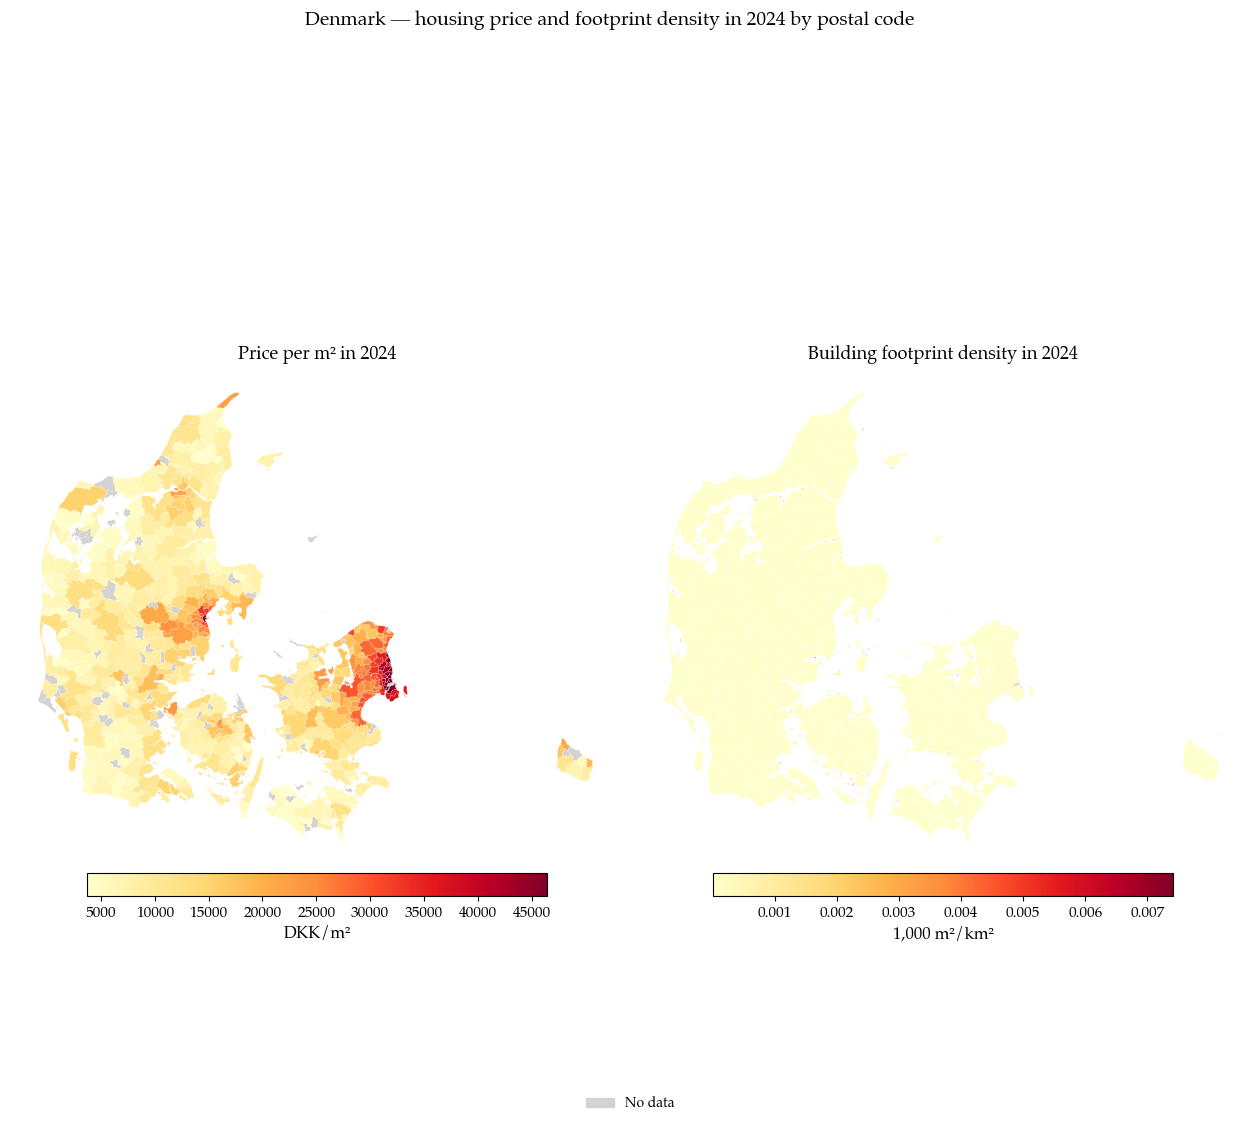

In [20]:

# ── 1. Choropleth helper ──────────────────────────────────────────────────────
def choropleth(ax, gdf, col, title, cmap='YlOrRd', unit='%', scale=1.0,
               vmin_q=0.02, vmax_q=0.98):
    vals  = gdf[col].dropna() * scale
    vmin  = vals.quantile(vmin_q)
    vmax  = vals.quantile(vmax_q)
    norm  = Normalize(vmin=vmin, vmax=vmax)
    sm    = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    valid = gdf[col].notna()
    gdf[~valid].plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.1)

    # Build a temporary series with the scaled values for plotting
    scaled_col = '_scaled_' + col
    gdf_plot = gdf.assign(**{scaled_col: gdf[col] * scale})
    gdf_plot[valid].plot(ax=ax, column=scaled_col, cmap=cmap, norm=norm,
                         edgecolor='white', linewidth=0.1)

    plt.colorbar(sm, ax=ax, orientation='horizontal', location='bottom',
                 shrink=0.75, label=unit, pad=0.01)
    ax.set_title(title, fontsize=13, pad=8)
    ax.axis('off')

# ── 2. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_2024',
           'Price per m\u00b2 in 2024',
           cmap='YlOrRd', unit='DKK/m\u00b2')

choropleth(axes[1], postal, 'density_2024',
           'Building footprint density in 2024',
           cmap='YlOrRd', unit='1,000 m\u00b2/km\u00b2', scale=1e-3, vmax_q=0.90)

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density in 2024 by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Plotting changes from 1992 to 2024 (figure 2.3)

/opt/anaconda3/lib/python3.12/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  ax.figure.canvas.draw_idle()
/opt/anaconda3/lib/python3.12/site-packages/geopandas/plotting.py:950: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  ax.figure.canvas.draw_idle()
/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_39216/1625065901.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


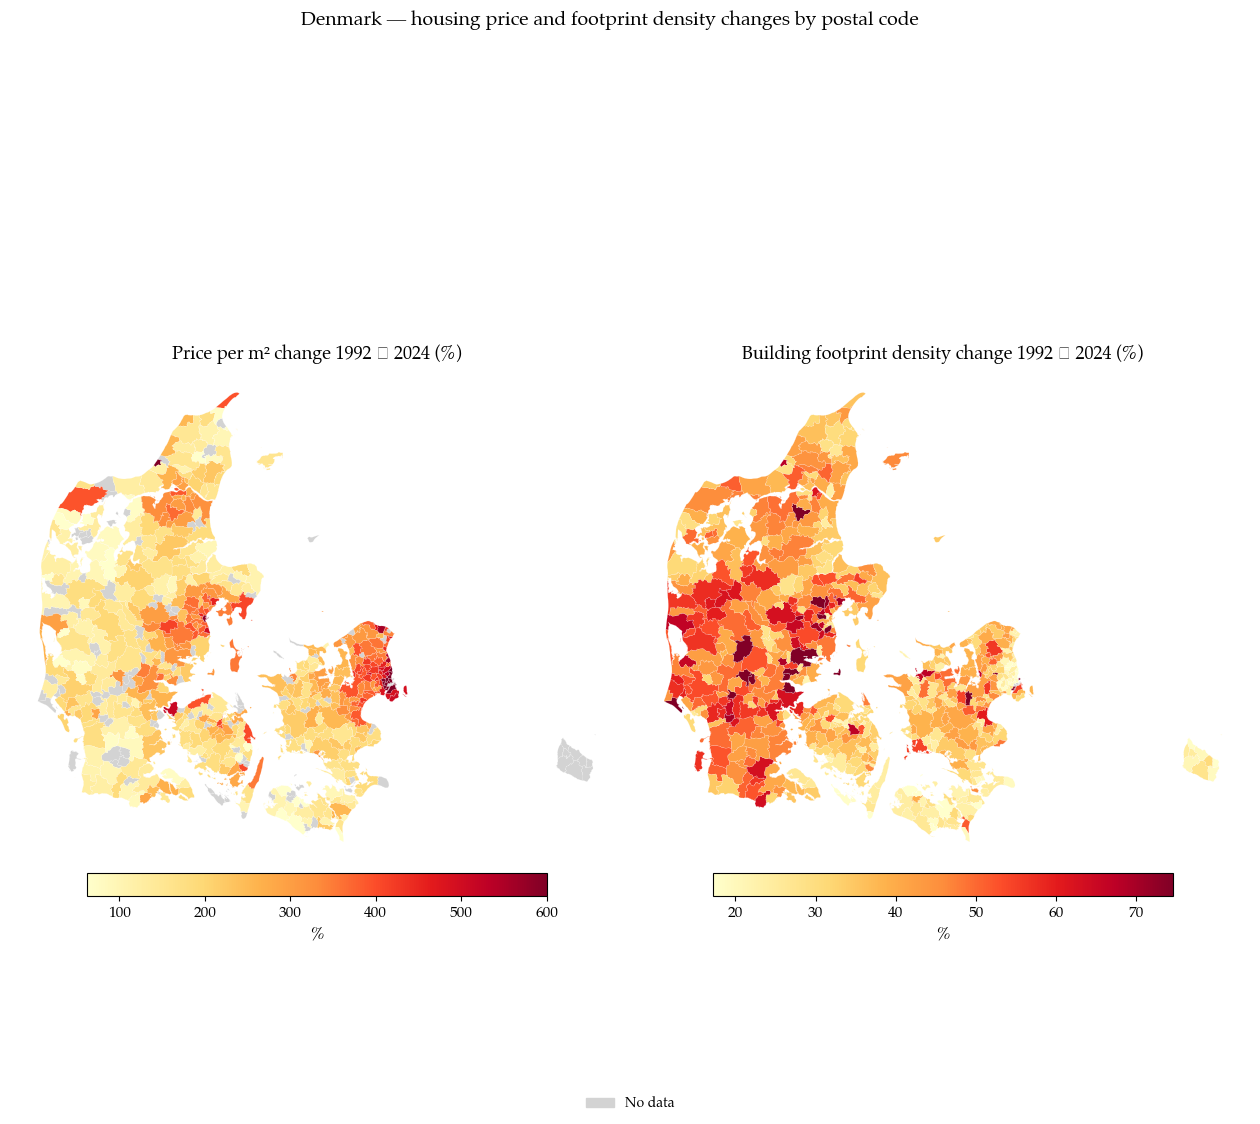

In [21]:

# ── 2. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_pct', 
           'Price per m\u00b2 change 1992 \u2192 2024 (%)')
choropleth(axes[1], postal, 'density_pct', 
           'Building footprint density change 1992 \u2192 2024 (%)')

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density changes by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  ax.figure.canvas.draw_idle()
/opt/anaconda3/lib/python3.12/site-packages/geopandas/plotting.py:950: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  ax.figure.canvas.draw_idle()
/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_39216/3226084456.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


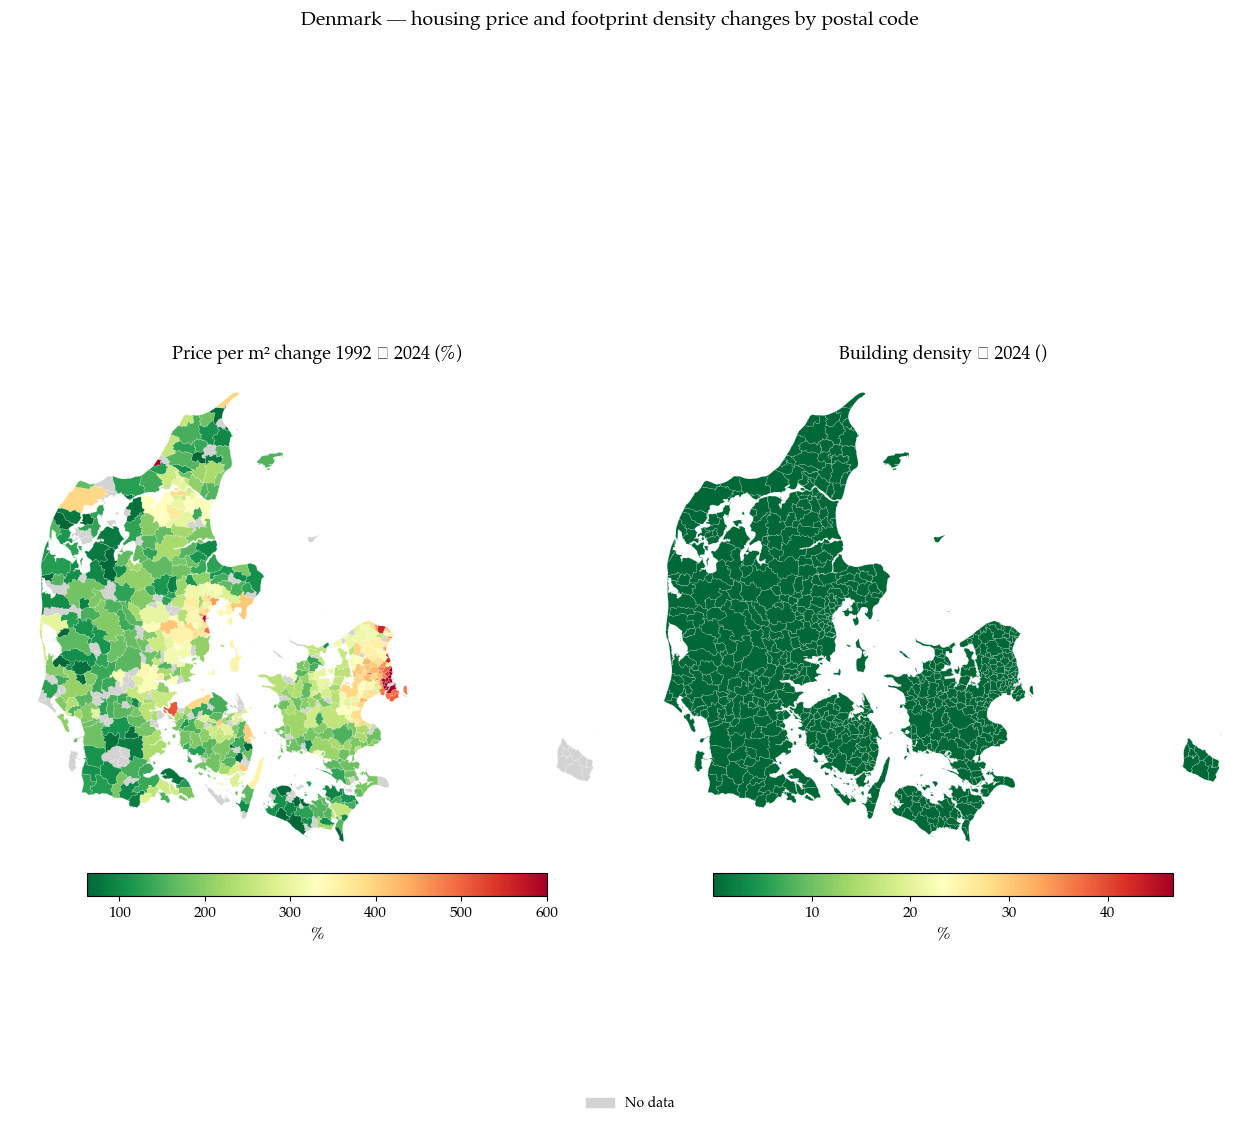

In [18]:
# ── 6. Draw ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 11),
                         gridspec_kw={'wspace': 0.02})

choropleth(axes[0], postal, 'price_pct',
           'Price per m\u00b2 change 1992 \u2192 2024 (%)')
choropleth(axes[1], postal, 'density_2024',
           'Building density \u2192 2024 ()')

grey_patch = mpatches.Patch(color='lightgrey', label='No data')
fig.legend(handles=[grey_patch], loc='lower center', fontsize=10, frameon=False)
fig.suptitle('Denmark \u2014 housing price and footprint density changes by postal code',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()